In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

In [ ]:
# 1. LOAD AND PREPROCESS DATA
# Load the Fashion-MNIST dataset instead of original mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [ ]:
# Define the text descriptions for the 10 categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training data shape:", x_train.shape)  # (60000, 28, 28)
print("Test data shape:", x_test.shape)      # (10000, 28, 28)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
# Reshape data to include the single grayscale color channel (height, width, channels)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

In [ ]:
# Normalize pixel values from 0-255 to a 0-1 range
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# Convert numerical target labels (0-9) to one-hot encoded vectors
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

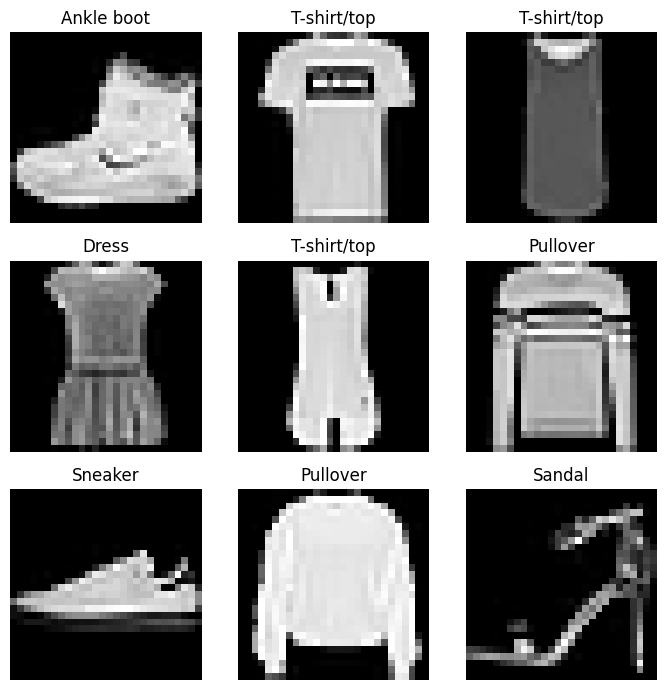

In [ ]:
# 2. VISUALIZE SAMPLES
# Display the first 9 clothing items to check the dataset
plt.figure(figsize=(7, 7))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 3. BUILD THE CNN MODEL
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block (Extracts deeper features)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 2D feature maps into a 1D vector
    layers.Flatten(),

    # Fully Connected Layers for Classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Helps reduce overfitting
    layers.Dense(10, activation='softmax') # 10 classes output probabilities
    ])

# Display a summary of the network layout
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 4. COMPILE AND TRAIN
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the network
history = model.fit(
    x_train, y_train_encoded,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test_encoded)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.8152 - loss: 0.5809 - val_accuracy: 0.8233 - val_loss: 0.5669
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.8301 - loss: 0.5073 - val_accuracy: 0.8607 - val_loss: 0.4672
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.8493 - loss: 0.4406 - val_accuracy: 0.8707 - val_loss: 0.5392
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.8555 - loss: 0.4180 - val_accuracy: 0.8750 - val_loss: 0.4137
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.8665 - loss: 0.3816 - val_accuracy: 0.8701 - val_loss: 0.4351



Final Test Accuracy: 84.73%


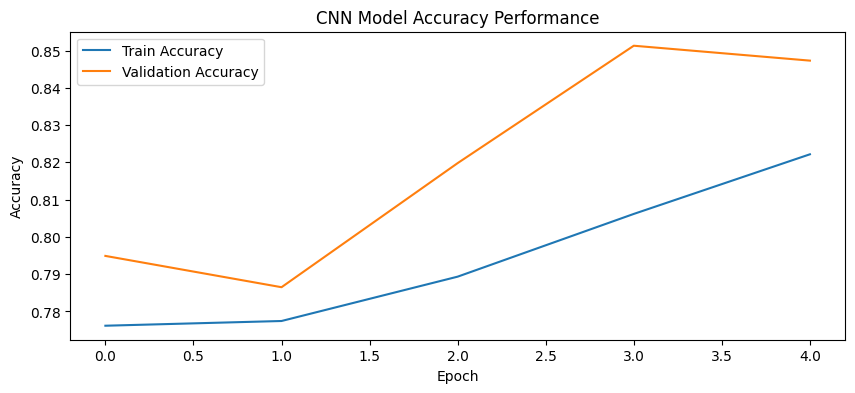

In [ ]:
# 5. EVALUATE MODEL PERFORMANCE
test_loss, test_acc = model.evaluate(x_test, y_test_encoded, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# Plot training & validation accuracy over epochs
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


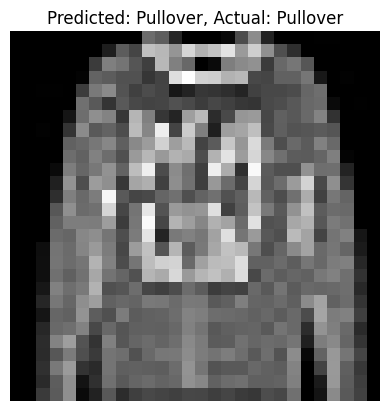

In [26]:
# Predict a single image (e.g., index 100)
index = 500
single_image = x_test[index].reshape(1, 28, 28, 1)

# Predict and show result
predicted_probs = model.predict(single_image)
predicted_num = np.argmax(predicted_probs)
actual_num = np.argmax(y_test_encoded[index]) # Using your encoded test labels

# Map the numbers back to the clothing names
predicted_label = class_names[predicted_num]
actual_label = class_names[actual_num]

# Display the image and the text results
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
plt.axis('off')
plt.show()